# Midpoint Rule

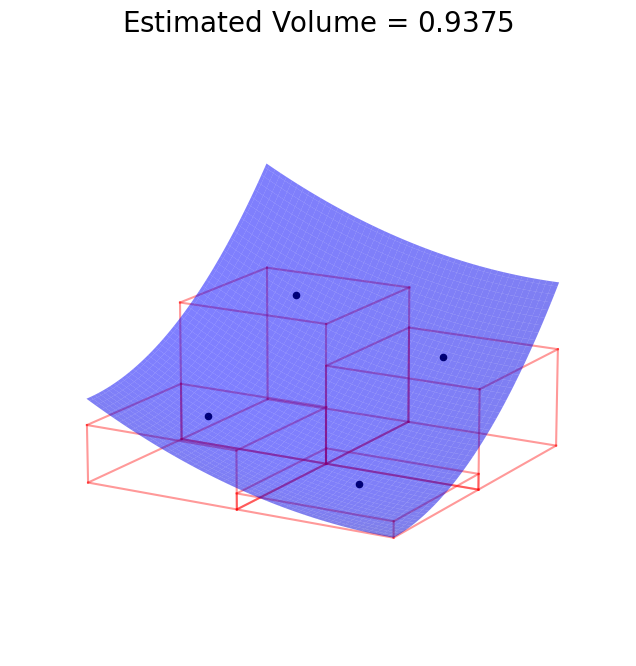

In [1]:
#@title Use the Midpoint Rule to Estimate an Integral

import numpy as np
import matplotlib.pyplot as plt

partition = "2 x 2" #@param ["2 x 2", "4 x 4", "8 x 8", "16 x 16"]

m = n = int(partition.split()[0])

a = 0
b = 1
c = 0
d = 1

def plot_tower (ax,x,y,dx,dy,z,col,alp):
    ax.plot ([x,x+dx],[y,y],[0,0],color=col,alpha=alp)
    ax.plot ([x,x],[y,y+dy],[0,0],color=col,alpha=alp)
    ax.plot ([x+dx,x+dx],[y,y+dy],[0,0],color=col,alpha=alp)
    ax.plot ([x,x+dx],[y+dy,y+dy],[0,0],color=col,alpha=alp)
    ax.plot ([x,x+dx],[y,y],[z,z],color=col,alpha=alp)
    ax.plot ([x,x],[y,y+dy],[z,z],color=col,alpha=alp)
    ax.plot ([x+dx,x+dx],[y,y+dy],[z,z],color=col,alpha=alp)
    ax.plot ([x,x+dx],[y+dy,y+dy],[z,z],color=col,alpha=alp)
    ax.plot ([x,x],[y,y],[0,z],color=col,alpha=alp)
    ax.plot ([x+dx,x+dx],[y,y],[0,z],color=col,alpha=alp)
    ax.plot ([x,x],[y+dy,y+dy],[0,z],color=col,alpha=alp)
    ax.plot ([x+dx,x+dx],[y+dy,y+dy],[0,z],color=col,alpha=alp)

def plot_towers (ax,a,b,c,d,m,n,fun,col='r',alp=0.4):
    dx = (b-a)/m
    dy = (d-c)/n
    x = a
    y = c
    for i in range(m):
        for j in range(n):
            xmid = x + dx/2
            ymid = y + dy/2
            fmid = fun(xmid,ymid)
            plot_tower (ax,x,y,dx,dy,fmid,col,alp)
            ax.scatter ([xmid],[ymid],[fmid],color='black')
            y += dy
        x += dx
        y = c

def midpoint_rule (a,b,c,d,m,n,fun):
    sum = 0
    dx = (b-a)/m
    dy = (d-c)/n
    x = a
    y = c
    for i in range(m):
        for j in range(n):
            xmid = x + dx/2
            ymid = y + dy/2
            fmid = fun(xmid,ymid)
            sum += fmid*dx*dy
            y += dy
        x += dx
        y = c
    return sum

def paraboloid (x,y):
    return 2*x**2 + y**2

plt.rcParams['figure.figsize'] = [10,8]

x = np.linspace(a,b,100)
y = np.linspace(c,d,100)
(X,Y) = np.meshgrid(x,y)
Z = paraboloid(X,Y)

ax = plt.axes(projection='3d')
ax._axis3don = False

ax.plot_surface(
    X,Y,Z,
    color='blue',
    alpha=0.5
)

plot_towers(
    ax,a,b,c,d,
    m,n,
    paraboloid
)

v = midpoint_rule(
    a,b,c,d,
    m,n,
    paraboloid
)

ax.set_title(
    r'Estimated Volume = $%s$' % v,
    fontsize=20
)

ax.view_init(15,210)

plt.show()